In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# ── Paths ──
data_path = '/kaggle/input/datasets/chrisfilo/urbansound8k'
meta_path = '/kaggle/input/datasets/chrisfilo/urbansound8k/UrbanSound8K.csv'

# ── Load metadata ──
df = pd.read_csv(meta_path)
print("✅ Metadata loaded:", df.shape)
print(df.head())

2026-03-14 01:08:03.203335: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773450483.481379      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773450483.536348      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773450483.976517      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773450483.976558      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773450483.976560      24 computation_placer.cc:177] computation placer alr

✅ Metadata loaded: (8732, 8)
      slice_file_name    fsID  start        end  salience  fold  classID  \
0    100032-3-0-0.wav  100032    0.0   0.317551         1     5        3   
1  100263-2-0-117.wav  100263   58.5  62.500000         1     5        2   
2  100263-2-0-121.wav  100263   60.5  64.500000         1     5        2   
3  100263-2-0-126.wav  100263   63.0  67.000000         1     5        2   
4  100263-2-0-137.wav  100263   68.5  72.500000         1     5        2   

              class  
0          dog_bark  
1  children_playing  
2  children_playing  
3  children_playing  
4  children_playing  


In [2]:
# -------------------------
# Feature extraction (106 features)
# -------------------------
def extract_features(audio, sample_rate):
    # ✅ Fix 1: Resample all audio to standard 22050 Hz
    target_sr = 22050
    if sample_rate != target_sr:
        audio = librosa.resample(audio, orig_sr=sample_rate, target_sr=target_sr)
        sample_rate = target_sr

    # ✅ Fix 2: Pad if audio is too short for n_fft
    min_length = 2048
    if len(audio) < min_length:
        audio = np.pad(audio, (0, min_length - len(audio)), mode='constant')

    # ✅ Fix 3: Dynamic n_fft based on signal length
    n_fft = min(2048, len(audio))

    # MFCCs → 40 values
    mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40, n_fft=n_fft)
    mfccs_scaled = np.mean(mfccs.T, axis=0)

    # Mel Spectrogram → 64 values (reduced from 128 to avoid empty filters)
    mel_spectrogram = librosa.feature.melspectrogram(y=audio, sr=sample_rate, n_mels=64, n_fft=n_fft)
    mel_scaled = np.mean(librosa.power_to_db(mel_spectrogram).T, axis=0)

    # Zero Crossing Rate → 1 value
    zcr = librosa.feature.zero_crossing_rate(y=audio)
    zcr_scaled = np.mean(zcr.T, axis=0)

    # RMSE → 1 value
    rmse = librosa.feature.rms(y=audio)
    rmse_scaled = np.mean(rmse.T, axis=0)

    # Total: 40 + 64 + 1 + 1 = 106 features
    return np.concatenate((mfccs_scaled, mel_scaled, zcr_scaled, rmse_scaled))


# -------------------------
# Data augmentation
# -------------------------
def augment_audio(audio, sample_rate):
    # Original
    original = audio

    # Time stretch
    try:
        stretched = librosa.effects.time_stretch(audio, rate=1.1)
    except:
        stretched = audio

    # Pitch shift
    shifted = librosa.effects.pitch_shift(audio, sr=sample_rate, n_steps=2)

    return [original, stretched, shifted]


# -------------------------
# Build dataset with fold tracking
# -------------------------
features = []
labels   = []
folds    = []

for i, row in tqdm(df.iterrows(), total=len(df), desc="Extracting features"):
    file_path = os.path.join(data_path, f"fold{row['fold']}", row['slice_file_name'])
    try:
        audio, sr = librosa.load(file_path, sr=None, duration=5)
        for aug_audio in augment_audio(audio, sr):
            features.append(extract_features(aug_audio, sr))
            labels.append(row['class'])
            folds.append(row['fold'])
    except Exception as e:
        print(f"⚠️ Skipped {row['slice_file_name']}: {e}")

X     = np.array(features, dtype='float32')
y     = np.array(labels)
folds = np.array(folds)

print("\n✅ Dataset ready!")
print(f"   X shape    : {X.shape}")       # (26196, 106)
print(f"   y shape    : {y.shape}")       # (26196,)
print(f"   folds shape: {folds.shape}")   # (26196,)
print(f"   Classes    : {np.unique(y)}")

Extracting features: 100%|██████████| 8732/8732 [30:56<00:00,  4.70it/s]


✅ Dataset ready!
   X shape    : (26196, 106)
   y shape    : (26196,)
   folds shape: (26196,)
   Classes    : ['air_conditioner' 'car_horn' 'children_playing' 'dog_bark' 'drilling'
 'engine_idling' 'gun_shot' 'jackhammer' 'siren' 'street_music']


In [3]:
# -------------------------
# Build model (106 input features)
# -------------------------
def build_model():
    inputs = layers.Input(shape=(106,))       # ✅ 40+64+1+1 = 106
    x = layers.Reshape((53, 2))(inputs)       # ✅ 53×2 = 106

    # Conv1D Block 1
    x = layers.Conv1D(64, kernel_size=5, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)   # → (26, 64)

    # Conv1D Block 2
    x = layers.Conv1D(128, kernel_size=5, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)   # → (13, 128)

    # BiLSTM layers
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
    bilstm_output = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)

    # Multi-Head Attention
    attn_output = layers.MultiHeadAttention(num_heads=4, key_dim=32)(bilstm_output, bilstm_output)

    # Residual connection
    x = layers.Add()([bilstm_output, attn_output])
    x = layers.LayerNormalization()(x)

    # Global Average Pooling
    x = layers.GlobalAveragePooling1D()(x)

    # Dense layers
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)

    # Output
    outputs = layers.Dense(10, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ── Test model builds correctly ──
test_model = build_model()
test_model.summary()

I0000 00:00:1773452365.491592      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 106)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 53, 2)     │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 53, 64)    │        704 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 53, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 26, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 26, 128)   │     41,088 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 26, 128)   │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 13, 128)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 13, 256)   │    263,168 │ max_pooling1d_1[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 13, 128)   │    164,352 │ bidirectional[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 13, 128)   │     66,048 │ bidirectional_1[… │
│ (MultiHeadAttentio… │                   │            │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 13, 128)   │          0 │ bidirectional_1[… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 13, 128)   │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     33,024 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 10)        │      1,290 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 603,594 (2.30 MB)

 Trainable params: 603,210 (2.30 MB)

 Non-trainable params: 384 (1.50 KB)

Classes: ['air_conditioner' 'car_horn' 'children_playing' 'dog_bark' 'drilling'
 'engine_idling' 'gun_shot' 'jackhammer' 'siren' 'street_music']

  Fold 1/10 — Test fold: 1
  Train: (23577, 106) | Test: (2619, 106)

  🚀 Training Fold 1...
Epoch 1/50


I0000 00:00:1773452374.525073      76 cuda_dnn.cc:529] Loaded cuDNN version 91002


664/664 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4112 - loss: 1.6679
Epoch 1: val_accuracy improved from -inf to 0.44275, saving model to /kaggle/working/best_model_fold1.keras
664/664 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.4114 - loss: 1.6674 - val_accuracy: 0.4427 - val_loss: 1.8609
Epoch 2/50
662/664 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7602 - loss: 0.7662
Epoch 2: val_accuracy did not improve from 0.44275
664/664 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.7603 - loss: 0.7659 - val_accuracy: 0.4215 - val_loss: 2.2978
Epoch 3/50
664/664 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8439 - loss: 0.4948
Epoch 3: val_accuracy improved from 0.44275 to 0.45505, saving model to /kaggle/working/best_model_fold1.keras
664/664 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.8439 - loss: 0.4947 - val_accuracy: 0.4550 - val_loss: 2.3310
Epoch 4/50
663/664 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8856 - loss: 0.3554
Epoch 4: val_accuracy did not improv

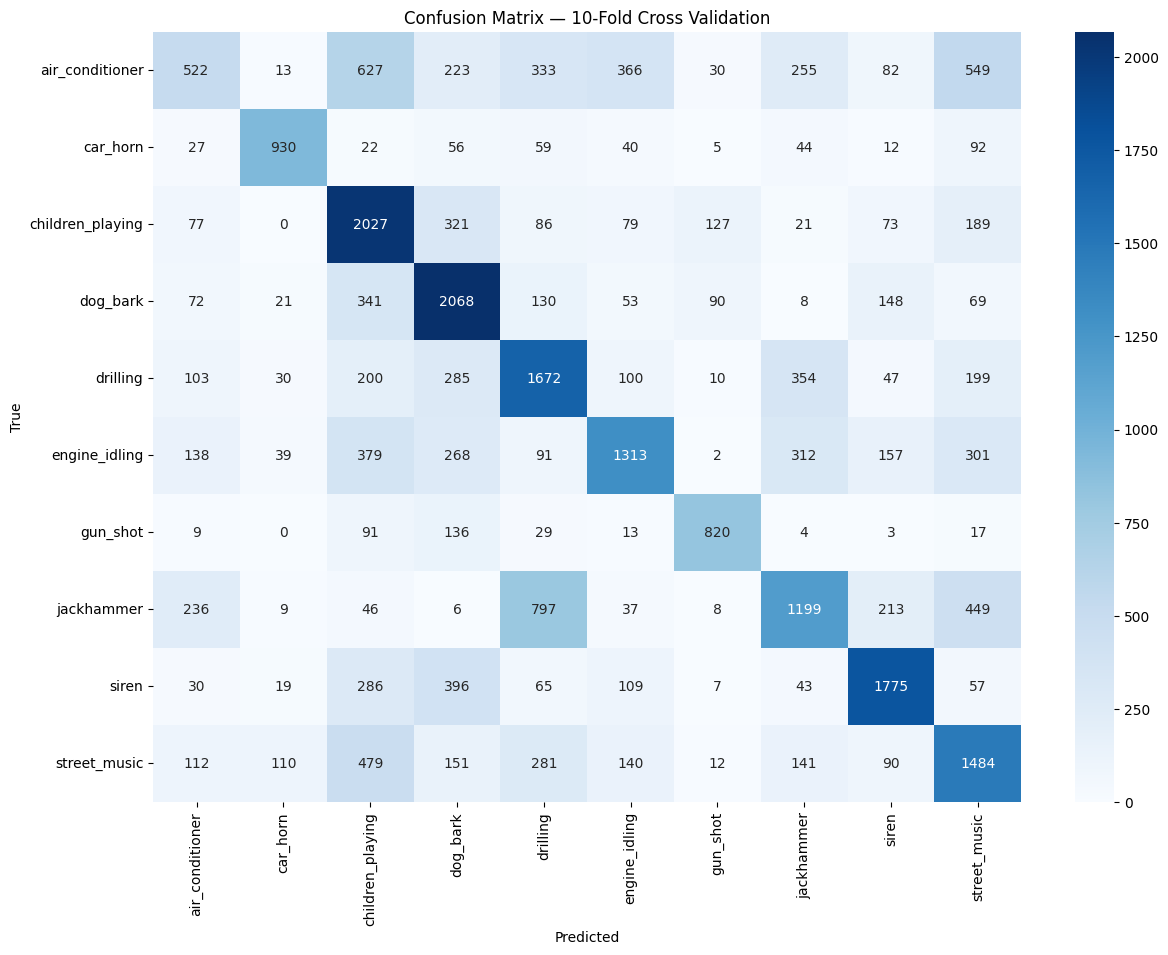

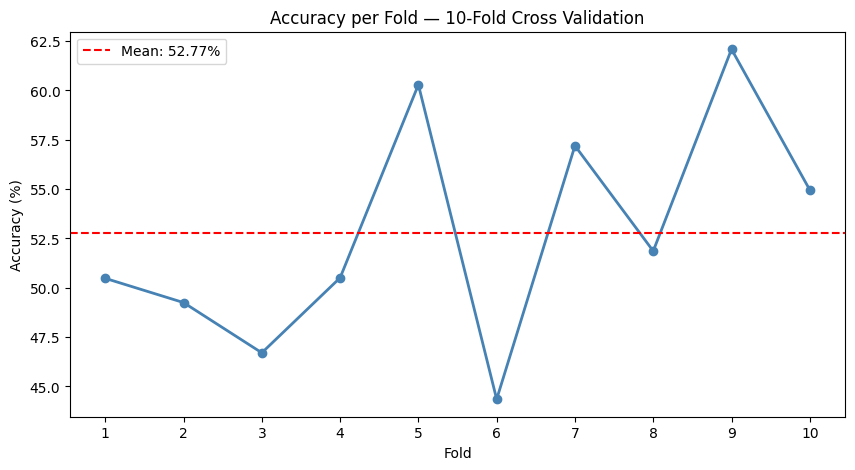

In [4]:
# -------------------------
# Label encoder
# -------------------------
le = LabelEncoder()
le.fit(y)
y_encoded = le.transform(y)
print("Classes:", le.classes_)

# -------------------------
# 10-Fold Cross Validation
# -------------------------
all_accuracies = []
all_losses     = []
all_y_true     = []
all_y_pred     = []

for test_fold in range(1, 11):
    print(f"\n{'='*50}")
    print(f"  Fold {test_fold}/10 — Test fold: {test_fold}")
    print(f"{'='*50}")

    # ── Split by predefined fold ──
    train_idx = np.where(folds != test_fold)[0]
    test_idx  = np.where(folds == test_fold)[0]

    X_train_fold = X[train_idx]
    X_test_fold  = X[test_idx]
    y_train_fold = to_categorical(y_encoded[train_idx], num_classes=10)
    y_test_fold  = to_categorical(y_encoded[test_idx],  num_classes=10)

    print(f"  Train: {X_train_fold.shape} | Test: {X_test_fold.shape}")

    # ── Build fresh model for each fold ──
    model = build_model()

    checkpoint = ModelCheckpoint(
        f'/kaggle/working/best_model_fold{test_fold}.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )

    # ── Train ──
    print(f"\n  🚀 Training Fold {test_fold}...")
    with tf.device('/GPU:0'):
        model.fit(
            X_train_fold, y_train_fold,
            validation_split=0.1,
            epochs=50,
            batch_size=32,
            callbacks=[checkpoint],
            verbose=1
        )

    # ── Load best weights and evaluate ──
    model.load_weights(f'/kaggle/working/best_model_fold{test_fold}.keras')
    loss, accuracy = model.evaluate(X_test_fold, y_test_fold, verbose=0)
    print(f"\n  ✅ Fold {test_fold} → Accuracy: {accuracy*100:.2f}% | Loss: {loss:.4f}")

    all_accuracies.append(accuracy)
    all_losses.append(loss)
    all_y_true.extend(y_encoded[test_idx])
    all_y_pred.extend(np.argmax(model.predict(X_test_fold), axis=1))

# -------------------------
# Final Results
# -------------------------
print(f"\n{'='*50}")
print(f"  10-FOLD CROSS VALIDATION RESULTS")
print(f"{'='*50}")
for i, (acc, loss) in enumerate(zip(all_accuracies, all_losses), 1):
    print(f"  Fold {i:2d} → Accuracy: {acc*100:.2f}%  |  Loss: {loss:.4f}")
print(f"{'─'*50}")
print(f"  Mean Accuracy : {np.mean(all_accuracies)*100:.2f}%")
print(f"  Std Deviation : {np.std(all_accuracies)*100:.2f}%")
print(f"  Best Fold     : Fold {np.argmax(all_accuracies)+1} ({max(all_accuracies)*100:.2f}%)")
print(f"  Worst Fold    : Fold {np.argmin(all_accuracies)+1} ({min(all_accuracies)*100:.2f}%)")

# ── Classification Report ──
print("\nClassification Report:")
print(classification_report(all_y_true, all_y_pred, target_names=le.classes_))

# ── Confusion Matrix ──
conf_matrix = confusion_matrix(all_y_true, all_y_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — 10-Fold Cross Validation")
plt.savefig('/kaggle/working/confusion_matrix_cv.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Accuracy per Fold Plot ──
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), [a*100 for a in all_accuracies],
         marker='o', color='steelblue', linewidth=2)
plt.axhline(y=np.mean(all_accuracies)*100, color='red', linestyle='--',
            label=f'Mean: {np.mean(all_accuracies)*100:.2f}%')
plt.xlabel("Fold")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy per Fold — 10-Fold Cross Validation")
plt.xticks(range(1, 11))
plt.legend()
plt.savefig('/kaggle/working/accuracy_per_fold.png', dpi=300, bbox_inches='tight')
plt.show()